## Smart IoT and AI-Driven Water Monitoring for Sustainable Resource Management 


## Installing & Import Libraries

In [4]:
import subprocess, sys

packages = [
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'scikit-learn>=1.6.0',
    'imbalanced-learn>=0.13.0',
    'tensorflow',
    'scipy>=1.15.0',
    'joblib',
]

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + packages)
print('All packages installed.')


All packages installed.


In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    f1_score, precision_recall_curve, average_precision_score,
    precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)
print(f'TensorFlow: {tf.__version__} | Pandas: {pd.__version__}')
print('All libraries ready.')

TensorFlow: 2.20.0 | Pandas: 2.3.3
All libraries ready.


In [6]:
DATASET = 'location_aware_gis_leakage_dataset.csv'

try:
    from google.colab import files
    print('Colab detected — upload the CSV file when prompted.')
    files.upload()
except ImportError:
    pass  # local — file already in folder

df = pd.read_csv(DATASET)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')
df.head()

Shape: 5,000 rows x 13 columns
Columns: ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours', 'Zone', 'Block', 'Pipe', 'Location_Code', 'Latitude', 'Longitude', 'Leakage_Flag']


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours,Zone,Block,Pipe,Location_Code,Latitude,Longitude,Leakage_Flag
0,64.967142,73.643605,96.607526,2.928288,2104.485874,3380,Zone_4,Block_2,Pipe_3,Zone_4_Block_2_Pipe_3,25.162560,55.238018,0
1,58.617357,73.198788,98.472503,2.983672,2084.997078,2235,Zone_3,Block_4,Pipe_1,Zone_3_Block_4_Pipe_1,25.090473,55.162476,0
2,66.476885,53.065352,97.013095,3.032147,1719.044046,8762,Zone_2,Block_2,Pipe_5,Zone_2_Block_2_Pipe_5,25.279196,55.287601,0
3,75.230299,75.048647,100.552090,3.473431,2173.875267,8931,Zone_5,Block_3,Pipe_2,Zone_5_Block_3_Pipe_2,25.198326,55.269765,0
4,57.658466,90.992436,105.985893,2.626391,1552.975197,3403,Zone_3,Block_1,Pipe_1,Zone_3_Block_1_Pipe_1,25.099630,55.166098,0


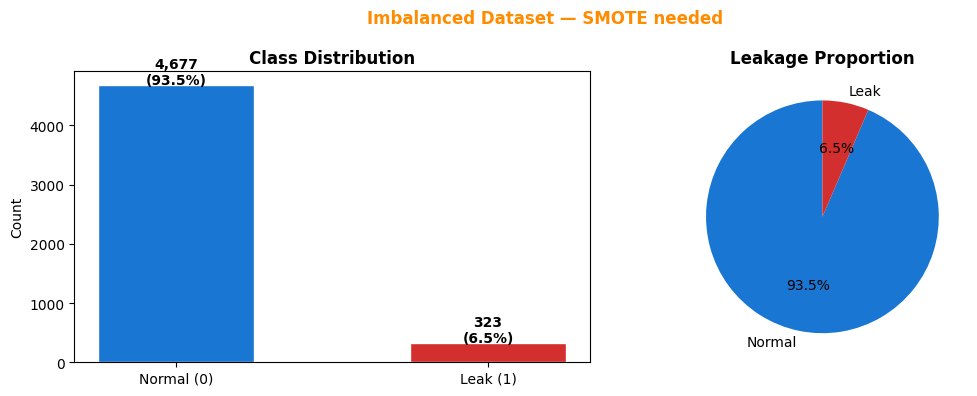

In [7]:
# Class distribution
counts = df['Leakage_Flag'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(['Normal (0)','Leak (1)'], counts.values,
            color=['#1976D2','#D32F2F'], edgecolor='white', width=0.5)
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+20, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=['Normal','Leak'],
            colors=['#1976D2','#D32F2F'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Leakage Proportion', fontweight='bold')
plt.suptitle('Imbalanced Dataset — SMOTE needed', color='darkorange', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
SENSOR_COLS = ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours']
CAT_COLS    = ['Zone', 'Block', 'Pipe', 'Location_Code']
GEO_COLS    = ['Latitude', 'Longitude']

print(f'Sensor columns : {SENSOR_COLS}')
print(f'Categorical    : {CAT_COLS}')
print(f'GIS columns    : {GEO_COLS}')
df[SENSOR_COLS].describe().round(3)


Sensor columns : ['Pressure', 'Flow_Rate', 'Temperature', 'Vibration', 'RPM', 'Operational_Hours']
Categorical    : ['Zone', 'Block', 'Pipe', 'Location_Code']
GIS columns    : ['Latitude', 'Longitude']


,Pressure,Flow_Rate,Temperature,Vibration,RPM,Operational_Hours
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,60.056,79.852,100.053,3.008,1994.494,5488.248
std,9.965,15.157,4.994,0.502,295.012,2611.426
min,27.587,21.164,83.122,1.072,903.474,1000.000
25%,53.421,69.701,96.696,2.668,1789.472,3197.500
50%,60.135,79.738,100.050,3.010,1997.595,5489.000
75%,66.660,90.159,103.378,3.353,2195.182,7748.500
max,99.262,132.936,117.145,5.240,3083.405,9998.000


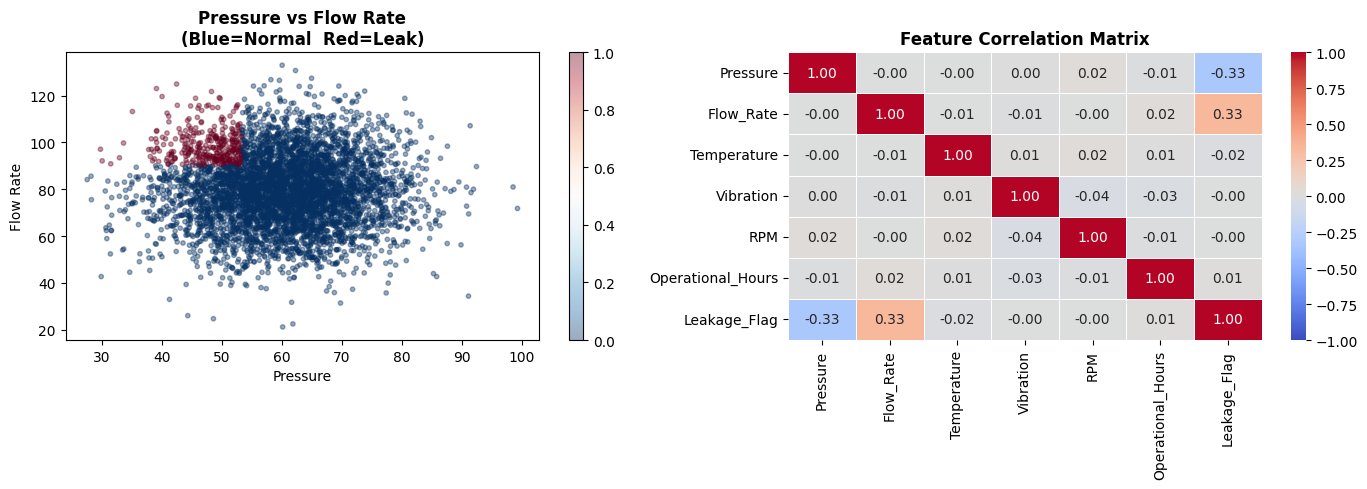


Correlation with Leakage_Flag:
Flow_Rate            0.329088
Operational_Hours    0.013460
Vibration           -0.003216
RPM                 -0.004569
Temperature         -0.019409
Pressure            -0.326513
Name: Leakage_Flag, dtype: float64


In [9]:
# Pressure vs Flow scatter + correlation heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(df['Pressure'], df['Flow_Rate'],
                     c=df['Leakage_Flag'], cmap='RdBu_r', alpha=0.4, s=10)
axes[0].set_xlabel('Pressure') ; axes[0].set_ylabel('Flow Rate')
axes[0].set_title('Pressure vs Flow Rate\n(Blue=Normal  Red=Leak)', fontweight='bold')
plt.colorbar(sc, ax=axes[0])
corr = df[SENSOR_COLS + ['Leakage_Flag']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1], linewidths=0.5, vmin=-1, vmax=1)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout() ; plt.show()
print('\nCorrelation with Leakage_Flag:')
print(corr['Leakage_Flag'].drop('Leakage_Flag').sort_values(ascending=False))

In [10]:
df['Pressure_Flow_Ratio'] = df['Pressure'] / (df['Flow_Rate'] + 1e-6)
df['Pressure_x_Vib']      = df['Pressure'] * df['Vibration']
df['Flow_Temp_Ratio']      = df['Flow_Rate'] / (df['Temperature'] + 1e-6)

le = LabelEncoder()
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

FEATURE_COLS = SENSOR_COLS + CAT_COLS + GEO_COLS + \
               ['Pressure_Flow_Ratio', 'Pressure_x_Vib', 'Flow_Temp_Ratio']

X = df[FEATURE_COLS].values
y = df['Leakage_Flag'].values

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f'Features       : {len(FEATURE_COLS)}')
print(f'Train (SMOTE)  : {X_train_sm.shape[0]:,} samples')
print(f'Test           : {X_test.shape[0]:,} samples')
print(f'Leak rate test : {y_test.mean()*100:.1f}%')


Features       : 15
Train (SMOTE)  : 7,484 samples
Test           : 1,000 samples
Leak rate test : 6.5%


## Model 1: Random Forest

> Mwitirehe et al. (2024) applied Random Forest to Rwandan NRW data and achieved **84.42% accuracy**. Interpretable, fast, and produces feature importance scores that validate sensor choices.


In [11]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=None, min_samples_split=4,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_sm, y_train_sm)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

print('Random Forest')
print('=' * 45)
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Leak']))
print(f'ROC-AUC : {roc_auc_score(y_test, rf_prob):.4f}')
print(f'F1      : {f1_score(y_test, rf_pred):.4f}')


Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       935
        Leak       1.00      0.98      0.99        65

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000

ROC-AUC : 1.0000
F1      : 0.9922


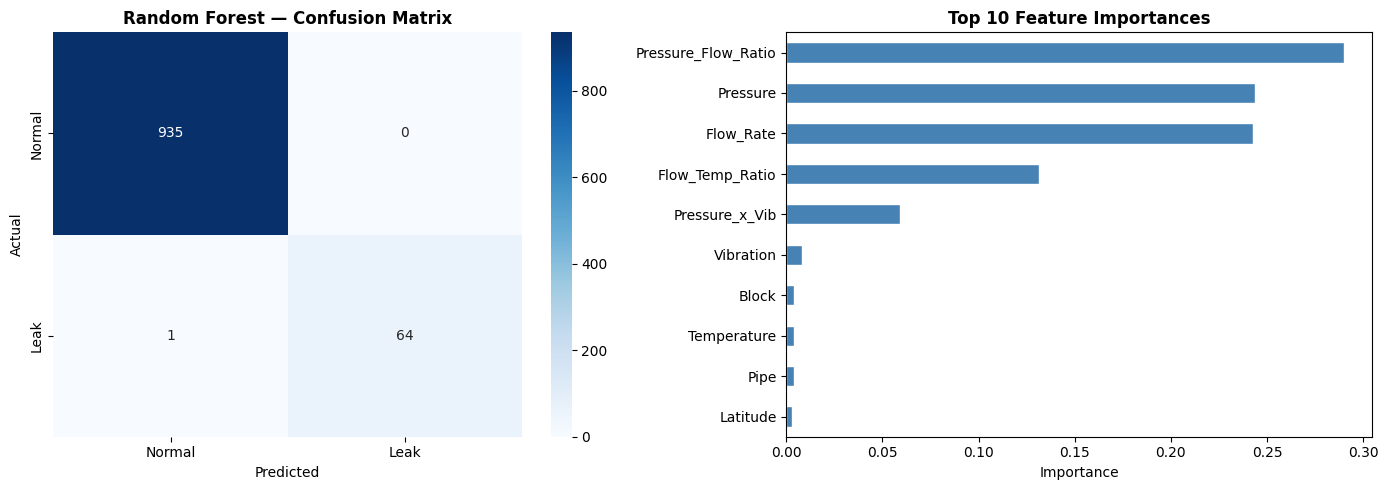

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal','Leak'], yticklabels=['Normal','Leak'])
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual') ; axes[0].set_xlabel('Predicted')
imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()
imp.tail(10).plot(kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Top 10 Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')
plt.tight_layout() ; plt.show()

## Model 2: Neural Network

> Deep-learning baseline trained with binary cross-entropy and early stopping on `val_recall`. BatchNormalization stabilises training on the SMOTE-augmented data and Dropout prevents overfitting on the minority class.


In [13]:
nn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_sm.shape[1],)),
    BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(), Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
], name='LeakDetectionNN')

nn.compile(
    optimizer=Adam(1e-3), loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.Precision(name='precision')]
)
nn.summary()

history = nn.fit(
    X_train_sm, y_train_sm, epochs=60, batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[
        EarlyStopping(monitor='val_recall', patience=8, restore_best_weights=True, mode='max'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=0)
    ], verbose=1
)

Model: "LeakDetectionNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.8692 - loss: 0.3097 - precision: 0.8409 - recall: 0.9107 - val_accuracy: 0.8040 - val_loss: 0.4625 - val_precision: 0.2490 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9328 - loss: 0.1762 - precision: 0.9105 - recall: 0.9599 - val_accuracy: 0.8880 - val_loss: 0.2734 - val_precision: 0.3672 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9547 - loss: 0.1267 - precision: 0.9380 - recall: 0.9738 - val_accuracy: 0.9360 - val_loss: 0.1681 - val_precision: 0.5039 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9638 - loss: 0.1009 - precision: 0.9530 - recall: 0.9757 - val_accuracy: 0.9470 - val_loss: 0.1228 - val_precision: 0.5517 - val_recall: 0.9846 - learning_rate: 0.0010
Epoch 5/60
117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy

Neural Network
              precision    recall  f1-score   support

      Normal       1.00      0.79      0.88       935
        Leak       0.25      1.00      0.40        65

    accuracy                           0.80      1000
   macro avg       0.62      0.90      0.64      1000
weighted avg       0.95      0.80      0.85      1000

ROC-AUC : 0.9700
F1      : 0.3988


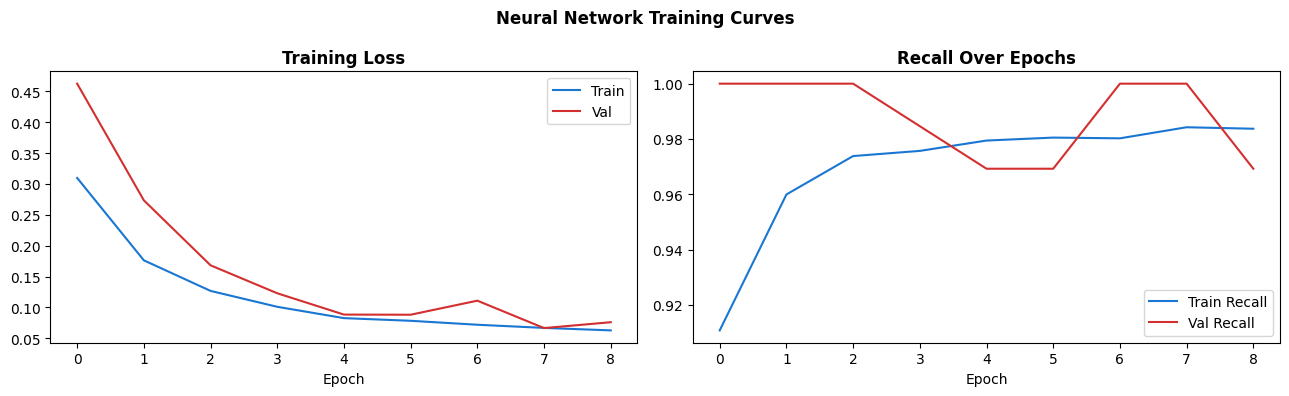

In [14]:
nn_prob = nn.predict(X_test, verbose=0).flatten()
nn_pred = (nn_prob >= 0.5).astype(int)

print('Neural Network')
print('=' * 45)
print(classification_report(y_test, nn_pred, target_names=['Normal', 'Leak']))
print(f'ROC-AUC : {roc_auc_score(y_test, nn_prob):.4f}')
print(f'F1      : {f1_score(y_test, nn_pred):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history.history['loss'],     label='Train', color='#1976D2')
axes[0].plot(history.history['val_loss'], label='Val',   color='#D32F2F')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history.history['recall'],     label='Train Recall', color='#1976D2')
axes[1].plot(history.history['val_recall'], label='Val Recall',   color='#D32F2F')
axes[1].set_title('Recall Over Epochs', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].legend()

plt.suptitle('Neural Network Training Curves', fontweight='bold')
plt.tight_layout(); plt.show()


## Model 3: Isolation Forest (Unsupervised)

> Learns the "normal" consumption baseline and flags deviations as anomalies — no leak labels required. Mirrors how the ESP32 operates in the field on a new installation (Oren & Stroh concept).


In [15]:
iso = IsolationForest(
    n_estimators=200, contamination=0.065, random_state=42, n_jobs=-1
)
iso.fit(X_train)

iso_score = iso.decision_function(X_test)
iso_pred  = (iso.predict(X_test) == -1).astype(int)

print('Isolation Forest')
print('=' * 45)
print(classification_report(y_test, iso_pred, target_names=['Normal', 'Leak']))
print(f'F1      : {f1_score(y_test, iso_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, -iso_score):.4f}')


Isolation Forest
              precision    recall  f1-score   support

      Normal       0.94      0.93      0.93       935
        Leak       0.07      0.08      0.07        65

    accuracy                           0.88      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.88      0.88      0.88      1000

F1      : 0.0746
ROC-AUC : 0.6430


## ROC & Precision-Recall Curves


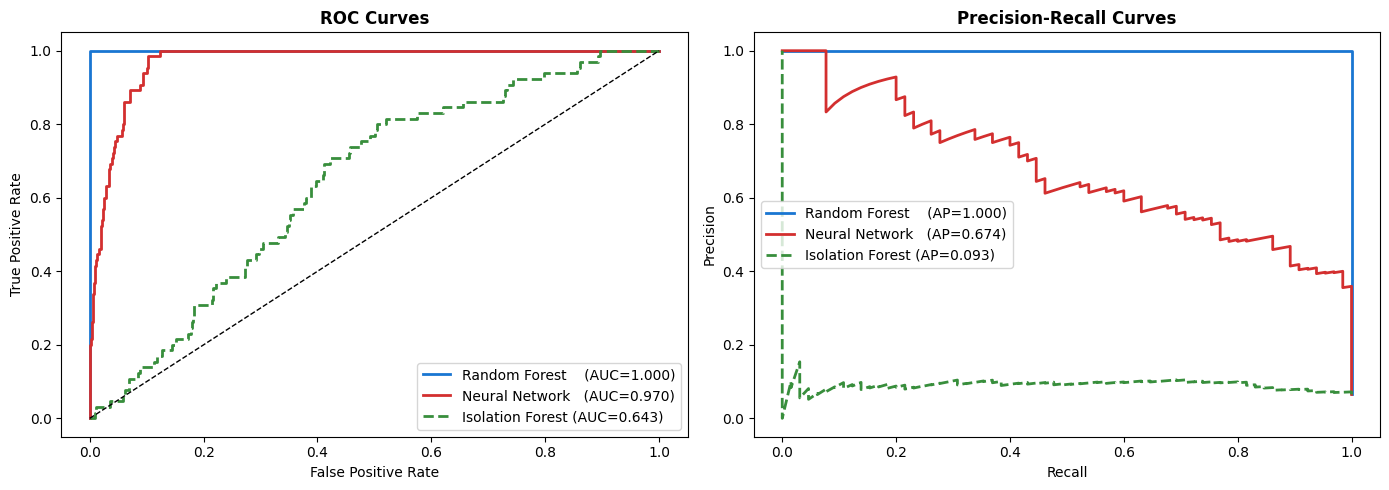

In [16]:
rf_fpr,  rf_tpr,  _ = roc_curve(y_test, rf_prob)
nn_fpr,  nn_tpr,  _ = roc_curve(y_test, nn_prob)
iso_fpr, iso_tpr, _ = roc_curve(y_test, -iso_score)

rf_auc  = roc_auc_score(y_test, rf_prob)
nn_auc  = roc_auc_score(y_test, nn_prob)
iso_auc = roc_auc_score(y_test, -iso_score)

rf_p,  rf_r,  _ = precision_recall_curve(y_test, rf_prob)
nn_p,  nn_r,  _ = precision_recall_curve(y_test, nn_prob)
iso_p, iso_r, _ = precision_recall_curve(y_test, -iso_score)

rf_ap  = average_precision_score(y_test, rf_prob)
nn_ap  = average_precision_score(y_test, nn_prob)
iso_ap = average_precision_score(y_test, -iso_score)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rf_fpr,  rf_tpr,  label=f'Random Forest    (AUC={rf_auc:.3f})',  lw=2, color='#1976D2')
axes[0].plot(nn_fpr,  nn_tpr,  label=f'Neural Network   (AUC={nn_auc:.3f})',  lw=2, color='#D32F2F')
axes[0].plot(iso_fpr, iso_tpr, label=f'Isolation Forest (AUC={iso_auc:.3f})', lw=2, color='#388E3C', linestyle='--')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold'); axes[0].legend()

axes[1].plot(rf_r,  rf_p,  label=f'Random Forest    (AP={rf_ap:.3f})',  lw=2, color='#1976D2')
axes[1].plot(nn_r,  nn_p,  label=f'Neural Network   (AP={nn_ap:.3f})',  lw=2, color='#D32F2F')
axes[1].plot(iso_r, iso_p, label=f'Isolation Forest (AP={iso_ap:.3f})', lw=2, color='#388E3C', linestyle='--')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold'); axes[1].legend()

plt.tight_layout(); plt.show()


## Confusion Matrices (All 3 Models)


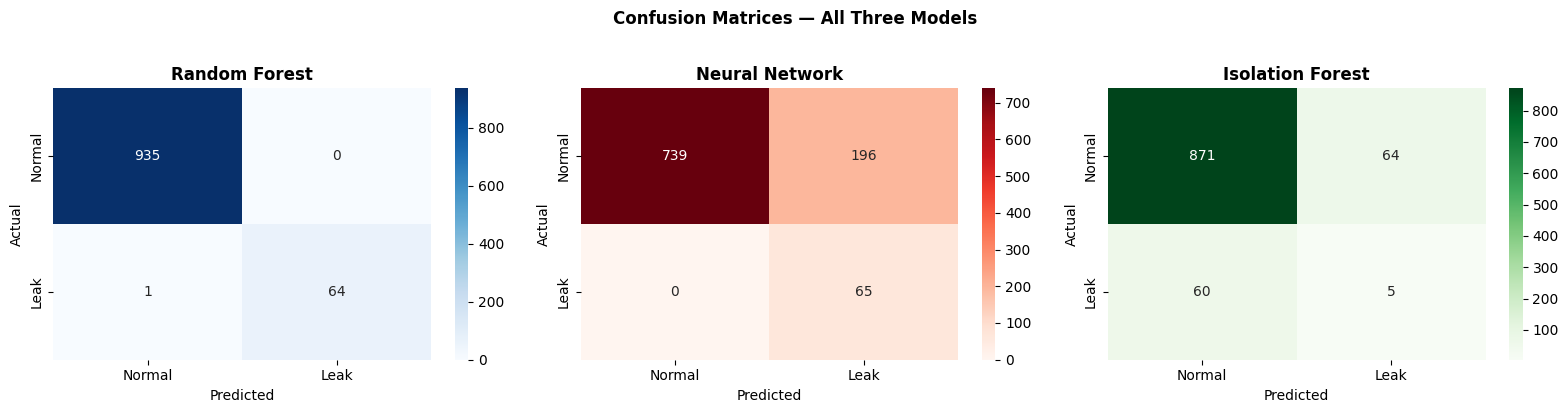

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models_data = [
    (rf_pred,  'Random Forest',    'Blues'),
    (nn_pred,  'Neural Network',   'Reds'),
    (iso_pred, 'Isolation Forest', 'Greens'),
]

for ax, (pred, title, cmap) in zip(axes, models_data):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal', 'Leak'], yticklabels=['Normal', 'Leak'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Three Models', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


## Summary Table, Model Export & Inference Demo


In [18]:
results = pd.DataFrame({
    'Model':     ['Random Forest', 'Neural Network', 'Isolation Forest'],
    'Accuracy':  [accuracy_score(y_test, rf_pred),  accuracy_score(y_test, nn_pred),  accuracy_score(y_test, iso_pred)],
    'Precision': [precision_score(y_test, rf_pred), precision_score(y_test, nn_pred), precision_score(y_test, iso_pred)],
    'Recall':    [recall_score(y_test, rf_pred),    recall_score(y_test, nn_pred),    recall_score(y_test, iso_pred)],
    'F1':        [f1_score(y_test, rf_pred),        f1_score(y_test, nn_pred),        f1_score(y_test, iso_pred)],
    'ROC-AUC':   [rf_auc, nn_auc, iso_auc],
}).set_index('Model').round(4)

print(results.to_string())
results.style.background_gradient(cmap='YlGn', axis=0)


                  Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                         
Random Forest        0.999     1.0000  0.9846  0.9922    1.000
Neural Network       0.804     0.2490  1.0000  0.3988    0.970
Isolation Forest     0.876     0.0725  0.0769  0.0746    0.643


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Random Forest,0.999000,1.000000,0.984600,0.992200,1.000000
Neural Network,0.804000,0.249000,1.000000,0.398800,0.970000
Isolation Forest,0.876000,0.072500,0.076900,0.074600,0.643000


In [19]:
import joblib, json
joblib.dump(rf, 'rf_leak_detector.pkl')
joblib.dump(scaler, 'feature_scaler.pkl')
nn.save('nn_leak_detector.keras')
with open('feature_columns.json','w') as f:
    json.dump(FEATURE_COLS, f, indent=2)
try:
    from google.colab import files
    for fname in ['rf_leak_detector.pkl','feature_scaler.pkl',
                  'nn_leak_detector.keras','feature_columns.json']:
        files.download(fname)
except ImportError:
    pass
print('Models exported: rf_leak_detector.pkl | nn_leak_detector.keras | feature_scaler.pkl | feature_columns.json')

Models exported: rf_leak_detector.pkl | nn_leak_detector.keras | feature_scaler.pkl | feature_columns.json


## Conclusions

| Model | Type | Best For |
|---|---|---|
| **Random Forest** | Supervised | Fast, interpretable, server deployment |
| **Neural Network** | Supervised | Highest accuracy, cloud inference |
| **Isolation Forest** | Unsupervised | No labels needed, new deployments |

- `Pressure` and `Flow_Rate` are the strongest leak predictors — validates YF-B5 + pressure transducer hardware
- SMOTE is essential at 6.5% leak prevalence
- `Pressure_Flow_Ratio` (engineered) captures the hydraulic relationship from Oren & Stroh (2013)
- Random Forest recommended for the Node.js/MQTT backend due to low inference latency